<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/QCA_prime_factorization10and15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.4 MB/s eta 0:00:00


--- Testing Best Evolved QCA Rules for Factorization ---

*** Testing on Original Training Set ***

--- Testing QCA Rules on: Original Training Set ---
  N=6: p_pred=2, q_pred=5 (p*q = 10). Factors INCORRECT. (One factor found)
  QCA Test Step 1/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  0.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 0 1 0 1]
  QCA Test Step 2/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.15 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 3/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 0 1]
  QCA Test Step 4/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.85 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 5/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 0 1]
  QCA Test Step 6/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.85 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 7/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 

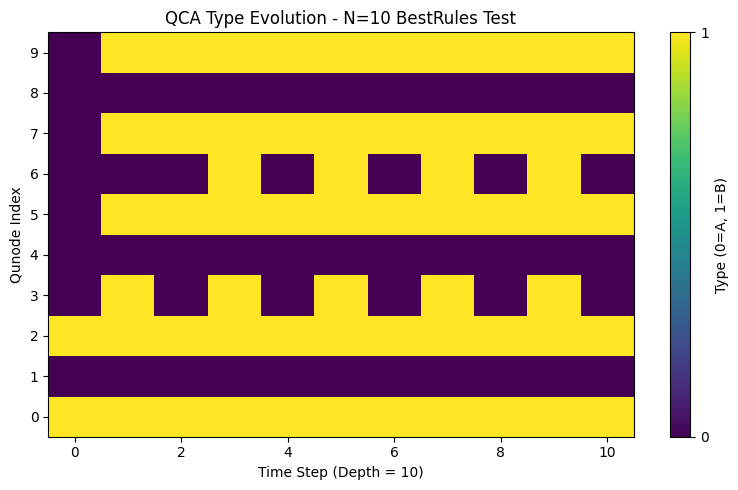


--- Interaction Circuit Visualization ---
Attempting Matplotlib drawer...
IPython display not available. Using text drawer.
     ┌───┐ init_prep      ┌───────────┐           interactions 
q_0: ┤ X ├─────░──────────┤1          ├────────────────░───────
     └───┘     ░     ┌───┐│           │                ░       
q_1: ──────────░─────┤ S ├┤           ├────────────────░───────
     ┌───┐     ░     ├───┤│           │                ░       
q_2: ┤ X ├─────░─────┤ H ├┤           ├────────────────░───────
     └───┘     ░     └───┘│           │     ┌───┐      ░       
q_3: ──────────░──────────┤  Rxx(π/4) ├──■──┤ X ├──────░───────
               ░          │           │  │  └───┘      ░       
q_4: ──────────░──────────┤           ├──┼─────────────░───────
               ░     ┌───┐│           │  │             ░       
q_5: ──────────░─────┤ H ├┤           ├──┼─────────────░───────
               ░     └───┘│           │  │             ░       
q_6: ──────────░──────────┤0          ├──┼─

In [3]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
from tqdm import tqdm # Keep tqdm for potential long QCA runs if needed
import math

# --- QCA Parameters (same as your GA run) ---
TYPE_A = 0
TYPE_B = 1

# --- QCA Class and is_prime_simple (Ensure these are your latest working versions) ---
# [YOUR QuantumCellularAutomaton CLASS DEFINITION GOES HERE - it should be the one from the GA run]
# [YOUR is_prime_simple FUNCTION GOES HERE - from the GA run]

# --- [PASTE QuantumCellularAutomaton class here] ---
GATES = { # Global GATES dictionary
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}
class QuantumCellularAutomaton: # Assuming this is your latest working version
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.simulator = AerSimulator(method='statevector')
        self.circuit_visualization_list = []

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _build_interaction_circuit(self) -> QuantumCircuit:
        qc_step = QuantumCircuit(self.num_qunodes, name=f"QCA_Interaction_Step")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_step.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.h(i)
        if self.num_qunodes > 0: qc_step.barrier(label="init_prep")
        interaction_applied_this_step = False; processed_qubits_in_specific_interactions = set()
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec, tuple) and len(op_spec) == 2:
                    gate_spec, qubit_indices_spec = op_spec
                    if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                            all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)): continue
                    qubit_indices = list(qubit_indices_spec)
                    if len(set(qubit_indices)) != len(qubit_indices): continue
                    op_to_apply = self._get_gate_object(gate_spec)
                    if op_to_apply.name.lower() != 'id':
                        if op_to_apply.num_qubits != len(qubit_indices): continue
                        try: qc_step.append(op_to_apply, qubit_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        else:
            # Fallback for dictionary-based type rules (not used in this best_rules test)
            if self.interaction_config.get("apply_general_nearest_neighbor", False):
                for i in range(self.num_qunodes):
                    q_j_idx = (i + 1) % self.num_qunodes
                    if self.num_qunodes >= 2:
                        type1, type2 = self.current_types[i], self.current_types[q_j_idx]
                        type_key_str = "".join(map(str, sorted((type1, type2))))
                        gate_spec_for_type = self.interaction_config.get(type_key_str, GATES["I"])
                        op_to_apply_type_based = self._get_gate_object(gate_spec_for_type)
                        if op_to_apply_type_based.name.lower() != 'id':
                            try: qc_step.append(op_to_apply_type_based, [i, q_j_idx]); interaction_applied_this_step = True
                            except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0 : qc_step.barrier(label="interactions")
        return qc_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def step(self) -> np.ndarray:
        interaction_qc = self._build_interaction_circuit()
        if not self.circuit_visualization_list: self.circuit_visualization_list.append(interaction_qc.copy())
        quantum_outcomes_p1 = np.zeros(self.num_qunodes); meaningful_ops = False
        if interaction_qc.num_qubits > 0:
            for instruction in interaction_qc.data:
                if instruction.operation.name.lower() not in ['barrier', 'id', 'snapshot', 'save_statevector']: meaningful_ops = True; break
        if interaction_qc.num_qubits > 0:
            if meaningful_ops or not self.quantum_outcome_history:
                try:
                    final_statevector_obj = Statevector(interaction_qc)
                    for i in range(self.num_qunodes):
                        probs_qi = final_statevector_obj.probabilities([i])
                        quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
                except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
            else:
                temp_qc_for_p1 = QuantumCircuit(self.num_qunodes)
                if self.initial_quantum_state_prep == "hadamard_all": [temp_qc_for_p1.h(i) for i in range(self.num_qunodes)]
                elif self.initial_quantum_state_prep == "basis_from_type":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.x(i)
                elif self.initial_quantum_state_prep == "mixed_A0_BH":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.h(i)
                if temp_qc_for_p1.num_qubits > 0:
                    try:
                        sv = Statevector(temp_qc_for_p1)
                        for i in range(self.num_qunodes):
                            quantum_outcomes_p1[i] = (sv.probabilities([i])[1] if len(sv.probabilities([i]))==2 else 0.0)
                    except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)
        self.current_types = new_types; self.type_history.append(self.current_types.copy())
        return quantum_outcomes_p1

    def run(self, num_steps: int, verbose: bool = False):
        # For testing, verbose is more useful, tqdm might be too much
        for step_num in range(num_steps):
            p1s = self.step()
            if verbose: print(f"  QCA Test Step {step_num+1}/{num_steps} -> P1s: {np.round(p1s,2)}, Types: {self.current_types}")
        # if verbose: print("  QCA Run for test completed.")

    def get_type_history_as_array(self) -> np.ndarray: return np.array(self.type_history)

    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = self.get_type_history_as_array()
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        fig_width = max(8, history_array.shape[0] * 0.3); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower')
        plt.xlabel(f"Time Step (Depth = {history_array.shape[0] - 1})"); plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]); plt.yticks(np.arange(self.num_qunodes))
        plt.tight_layout(); plt.show()

    def visualize_interaction_circuit(self, circuit_to_draw: Optional[QuantumCircuit] = None):
        # Visualizes a specific circuit, or the first stored one
        if circuit_to_draw is None and self.circuit_visualization_list:
            circuit_to_draw = self.circuit_visualization_list[0]

        if circuit_to_draw and circuit_to_draw.num_qubits > 0:
            print("\n--- Interaction Circuit Visualization ---")
            try:
                from IPython.display import display
                print("Attempting Matplotlib drawer...")
                display(circuit_to_draw.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Using text drawer."); print(circuit_to_draw.draw(output='text', fold=-1))
            except Exception as e: print(f"Error drawing circuit with mpl: {e}. Text:\n{circuit_to_draw.draw(output='text', fold=-1)}")
        elif circuit_to_draw: print("Circuit has no qubits to draw.")
        else: print("No circuit provided or stored for visualization.")
# --- [END QCA CLASS] ---

# --- [PASTE is_prime_simple function here] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---


# --- Function to Test a Specific QCA Rule Set ---
def test_specific_qca_rules(
    qca_rules: Dict,
    numbers_to_test: List[int],
    k_bits_N: int,
    k_bits_factor: int,
    T_max: int,
    test_set_name: str,
    visualize_one_case_N: Optional[int] = None # N for which to visualize circuit/evolution
):
    print(f"\n--- Testing QCA Rules on: {test_set_name} ---")
    correct_factorizations = 0
    correct_prime_factorizations = 0
    partial_success_count = 0 # Found at least one correct factor

    p_reg_start_idx = k_bits_N
    p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx
    q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx

    results = []

    for N_input in numbers_to_test:
        if N_input == 0: continue
        if N_input.bit_length() > k_bits_N:
            print(f"  N={N_input}: SKIPPED (too large for k_bits_N={k_bits_N})")
            results.append({"N": N_input, "status": "skipped_too_large"})
            continue

        initial_types = np.zeros(total_qca_qunodes, dtype=int)
        for i in range(k_bits_N): # MSB first encoding
            if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B

        qca = QuantumCellularAutomaton(
            num_qunodes=total_qca_qunodes, initial_types=initial_types,
            interaction_config=qca_rules["interaction_config"],
            type_update_rule_config=qca_rules["type_update_rule_config"],
            initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
        )
        # For testing, we might want to see QCA evolution steps for a specific case
        run_verbose = (N_input == visualize_one_case_N)
        qca.run(num_steps=T_max, verbose=run_verbose)

        final_types = qca.current_types
        p_pred_binary = final_types[p_reg_start_idx : p_reg_end_idx]
        q_pred_binary = final_types[q_reg_start_idx : q_reg_end_idx]
        p_pred = 0; q_pred = 0
        for bit_type in p_pred_binary: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
        for bit_type in q_pred_binary: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

        is_correct_product = (p_pred * q_pred == N_input) and (p_pred > 1) and (q_pred > 1)
        p_is_prime = is_prime_simple(p_pred)
        q_is_prime = is_prime_simple(q_pred)
        is_correct_prime_prod = is_correct_product and p_is_prime and q_is_prime

        # Check for partial success (at least one factor correct)
        one_factor_correct = False
        if p_pred > 1 and N_input % p_pred == 0: one_factor_correct = True
        if q_pred > 1 and N_input % q_pred == 0: one_factor_correct = True
        if is_correct_product: one_factor_correct = True # Implies both are factors

        result_str = f"  N={N_input}: p_pred={p_pred}, q_pred={q_pred} (p*q = {p_pred*q_pred}). "
        if is_correct_product:
            correct_factorizations += 1
            result_str += "Factors CORRECT. "
            if p_is_prime and q_is_prime:
                correct_prime_factorizations +=1
                result_str += "Both prime."
            elif p_is_prime or q_is_prime: result_str += "One prime."
            else: result_str += "Neither prime."
        else:
            result_str += "Factors INCORRECT."
            if one_factor_correct: result_str += " (One factor found)"


        print(result_str)
        results.append({
            "N": N_input, "p_pred": p_pred, "q_pred": q_pred, "product": p_pred*q_pred,
            "correct_prod": is_correct_product, "p_prime": p_is_prime, "q_prime": q_is_prime,
            "correct_prime_prod": is_correct_prime_prod, "one_factor_correct": one_factor_correct
            })

        if N_input == visualize_one_case_N:
            qca.plot_type_evolution(experiment_label=f"N={N_input} BestRules Test")
            qca.visualize_interaction_circuit() # Will show the static circuit defined by rules

    print(f"\nSummary for '{test_set_name}':")
    print(f"  Total numbers tested: {len(numbers_to_test)}")
    print(f"  Correct factorizations (p*q=N, p>1, q>1): {correct_factorizations} ({correct_factorizations/len(numbers_to_test)*100:.1f}%)")
    print(f"  Correct PRIME factorizations: {correct_prime_factorizations} ({correct_prime_factorizations/len(numbers_to_test)*100:.1f}%)")
    partially_successful_tests = sum(1 for r in results if r.get("one_factor_correct", False) and not r.get("correct_prod", False))
    print(f"  Additionally found one correct factor (but not full factorization): {partially_successful_tests}")
    return results


# --- Main Section to Test the Best Found Algorithm ---
if __name__ == "__main__":
    print("--- Testing Best Evolved QCA Rules for Factorization ---")

    # --- MANUALLY INPUT THE BEST RULES FOUND BY YOUR GA ---
    # This is from your previous GA output
    best_evolved_qca_rules = {
        "interaction_config": {
            "circuit_sequence": [
                ("H", (5,)), # Note: Qiskit expects tuple of ints for single qubit too
                ("RXX_PIO4", (6, 0)),
                ("CX", (3, 7)),
                ("S", (1,)),
                ("X", (3,)),
                ("H", (9,)),
                ("H", (2,)),
                ("SWAP", (7, 6))
            ]
            # "apply_general_nearest_neighbor": False # Assuming circuit_sequence is exclusive
        },
        "type_update_rule_config": {
            "name": "direct_p1_to_type",
            "p1_threshold_for_type_B": 0.03833197151484148
        },
        "initial_quantum_state_prep": "basis_from_type"
    }
    # Ensure the interaction_config matches how your _build_interaction_circuit expects it.
    # If it also needs "apply_general_nearest_neighbor": False, add it.
    # Based on the _build_interaction_circuit, if "circuit_sequence" is present, it takes precedence.

    # Factorization Problem Parameters (must match the GA run that found these rules)
    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3
    MAX_QCA_STEPS_FACTORIZATION = 10 # Same T_max used during evolution

    # Define Test Sets
    original_training_set = [6, 10, 14, 15, 21, 22, 25, 26, 33, 34, 35, 38, 39]

    # Unseen composite numbers (within k_bits_N limits)
    # N max is 15 for K_BITS_N_ENCODING = 4.
    # If we increase K_BITS_N_ENCODING for testing, we can test larger N.
    # For now, stick to N <= 15.
    unseen_composites = []
    all_N_up_to_15 = list(range(4, 16)) # Smallest composite is 4
    for n_test in all_N_up_to_15:
        if not is_prime_simple(n_test) and n_test not in original_training_set:
            unseen_composites.append(n_test)
    if not unseen_composites: # If all small composites were in training set
        unseen_composites = [4, 8, 9, 12] # Example if original set was too exhaustive

    prime_test_set = [2, 3, 5, 7, 11, 13] # Should ideally not be "factored" (p*q=N)

    # Run tests
    print("\n*** Testing on Original Training Set ***")
    results_train = test_specific_qca_rules(
        best_evolved_qca_rules, original_training_set,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Original Training Set",
        visualize_one_case_N=10 # Visualize for N=10
    )

    print("\n*** Testing on Unseen Composite Numbers ***")
    results_unseen = test_specific_qca_rules(
        best_evolved_qca_rules, unseen_composites,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Unseen Composites"
    )

    print("\n*** Testing on Prime Numbers (Expect No Factorization) ***")
    results_primes = test_specific_qca_rules(
        best_evolved_qca_rules, prime_test_set,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Prime Numbers Input"
    )

    print("\n--- Overall Test Conclusion ---")
    print("This test evaluated the QCA rules found by the GA.")
    print("Review the 'Correct factorizations' and 'Correct PRIME factorizations' for each set.")
    print("Performance on 'Unseen Composites' indicates generalization ability.")
    print("Performance on 'Prime Numbers Input' indicates if the QCA incorrectly produces factors for primes (ideally, it should output trivial 1*N or fail).")

    # Example: Save results to a file
    # test_summary = {
    #     "best_rules": best_evolved_qca_rules,
    #     "training_set_results": results_train,
    #     "unseen_composites_results": results_unseen,
    #     "prime_test_results": results_primes
    # }
    # with open("best_qca_factorizer_test_summary.json", "w") as f:
    #     json.dump(test_summary, f, indent=2)
    # print("\nTest summary saved to best_qca_factorizer_test_summary.json")